# 👥 Exercícios de Modelos Não Supervisionados de Machine Learning

**MBA em Data Science e Analytics (USP/ESALQ)**  
**Prof. Dr. Wilson Tarantin Junior**

---

Este notebook implementa uma **análise de segmentação de clientes** combinando duas técnicas:

- **K-Means** sobre as variáveis quantitativas (`Age`, `FamilySize`) para gerar os clusters
- **ACM (Análise de Correspondência Múltipla)** sobre as variáveis qualitativas + clusters para o mapa perceptual 3D

Dataset: segmentação de clientes — adaptado de [Kaggle: Customer Segmentation](https://www.kaggle.com/datasets/kaushiksuresh147/customer-segmentation)

## ⚙️ Instalação dos Pacotes

Execute diretamente no **terminal/console** (não dentro do notebook):

```bash
pip install pandas numpy matplotlib plotly scipy scikit-learn pingouin prince
```

## 📥 Importação dos Pacotes

- `pandas` / `numpy` — manipulação e cálculo numérico
- `matplotlib` — visualizações estáticas (Elbow, Silhueta)
- `scipy.stats.zscore` — padronização das variáveis quantitativas
- `sklearn.cluster.KMeans` — algoritmo de clusterização K-Means
- `sklearn.metrics.silhouette_score` — coeficiente de silhueta
- `pingouin` — ANOVA com saída detalhada
- `plotly.express` — mapa perceptual 3D interativo
- `prince` — ACM (Análise de Correspondência Múltipla)
- `scipy.stats.chi2_contingency` — testes qui-quadrado

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.cluster import KMeans
import pingouin as pg
import plotly.express as px
import prince
from scipy.stats import chi2_contingency
from sklearn.metrics import silhouette_score

## 📂 Carregamento do Banco de Dados

- Arquivo: `clientes_segmenta.xlsx`
- Contém informações demográficas e comportamentais de clientes
- Fonte: adaptado de [Kaggle: Customer Segmentation](https://www.kaggle.com/datasets/kaushiksuresh147/customer-segmentation)

In [22]:
clientes = pd.read_excel('clientes_segmenta.xlsx')
clientes.head()

,Gender,EverMarried,Age,Graduated,SpendingScore,FamilySize
0,Male,No,22,No,Low,4.0
1,Female,Yes,38,Yes,Average,3.0
2,Female,Yes,67,Yes,Low,1.0
3,Male,Yes,67,Yes,High,2.0
4,Female,Yes,40,Yes,High,6.0


## 🔍 Inspeção do Dataset

- Exibimos informações gerais: tipos de dados, contagem de não-nulos e presença de valores faltantes
- Necessário antes de qualquer análise para identificar problemas de qualidade de dados

In [23]:
clientes.info()
# Note que há valores faltantes "nan"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gender         8068 non-null   object 
 1   EverMarried    7928 non-null   object 
 2   Age            8068 non-null   int64  
 3   Graduated      7990 non-null   object 
 4   SpendingScore  8068 non-null   object 
 5   FamilySize     7733 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 378.3+ KB


## 🧹 Remoção de Valores Ausentes

- Removemos linhas com `NaN` para garantir que o K-Means e a ACM operem sobre dados completos
- Verificamos o tamanho do dataset após a remoção

In [24]:
clientes.dropna(inplace=True)

# Novas informações após limpeza
clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7538 entries, 0 to 8067
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gender         7538 non-null   object 
 1   EverMarried    7538 non-null   object 
 2   Age            7538 non-null   int64  
 3   Graduated      7538 non-null   object 
 4   SpendingScore  7538 non-null   object 
 5   FamilySize     7538 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 412.2+ KB


---
# 📍 Parte 1 — Clusterização K-Means (Variáveis Quantitativas)

## 🔀 Preparação das Variáveis Quantitativas

- O K-Means opera apenas sobre variáveis numéricas
- Selecionamos `Age` e `FamilySize` como base para a segmentação inicial

In [25]:
df_quanti = clientes[['Age', 'FamilySize']]
df_quanti.describe()

,Age,FamilySize
count,7538.000000,7538.000000
mean,43.524144,2.845450
std,16.612202,1.527899
min,18.000000,1.000000
25%,31.000000,2.000000
50%,41.000000,3.000000
75%,53.000000,4.000000
max,89.000000,9.000000


## 📏 Padronização via Z-Score

- As variáveis estão em unidades de medida distintas (`Age` em anos, `FamilySize` em pessoas)
- O Z-Score transforma cada variável para média **0** e desvio-padrão **1**, eliminando o viés de escala
- Sem padronização, variáveis com maior amplitude dominariam o cálculo das distâncias

In [26]:
df_quanti_pad = df_quanti.apply(zscore, ddof=1)
df_quanti_pad.describe().round(4)

,Age,FamilySize
count,7538.0000,7538.0000
mean,-0.0000,0.0000
std,1.0000,1.0000
min,-1.5365,-1.2078
25%,-0.7539,-0.5533
50%,-0.1519,0.1012
75%,0.5704,0.7556
max,2.7375,4.0281


## 📉 Método Elbow — Definição do Número de Clusters

- Testa K de 1 a 10 e registra o **WCSS** (Within-Cluster Sum of Squares) de cada configuração
- O ponto de inflexão da curva (“cotovelo”) indica o K ótimo, onde o ganho marginal de redução do WCSS começa a diminuir

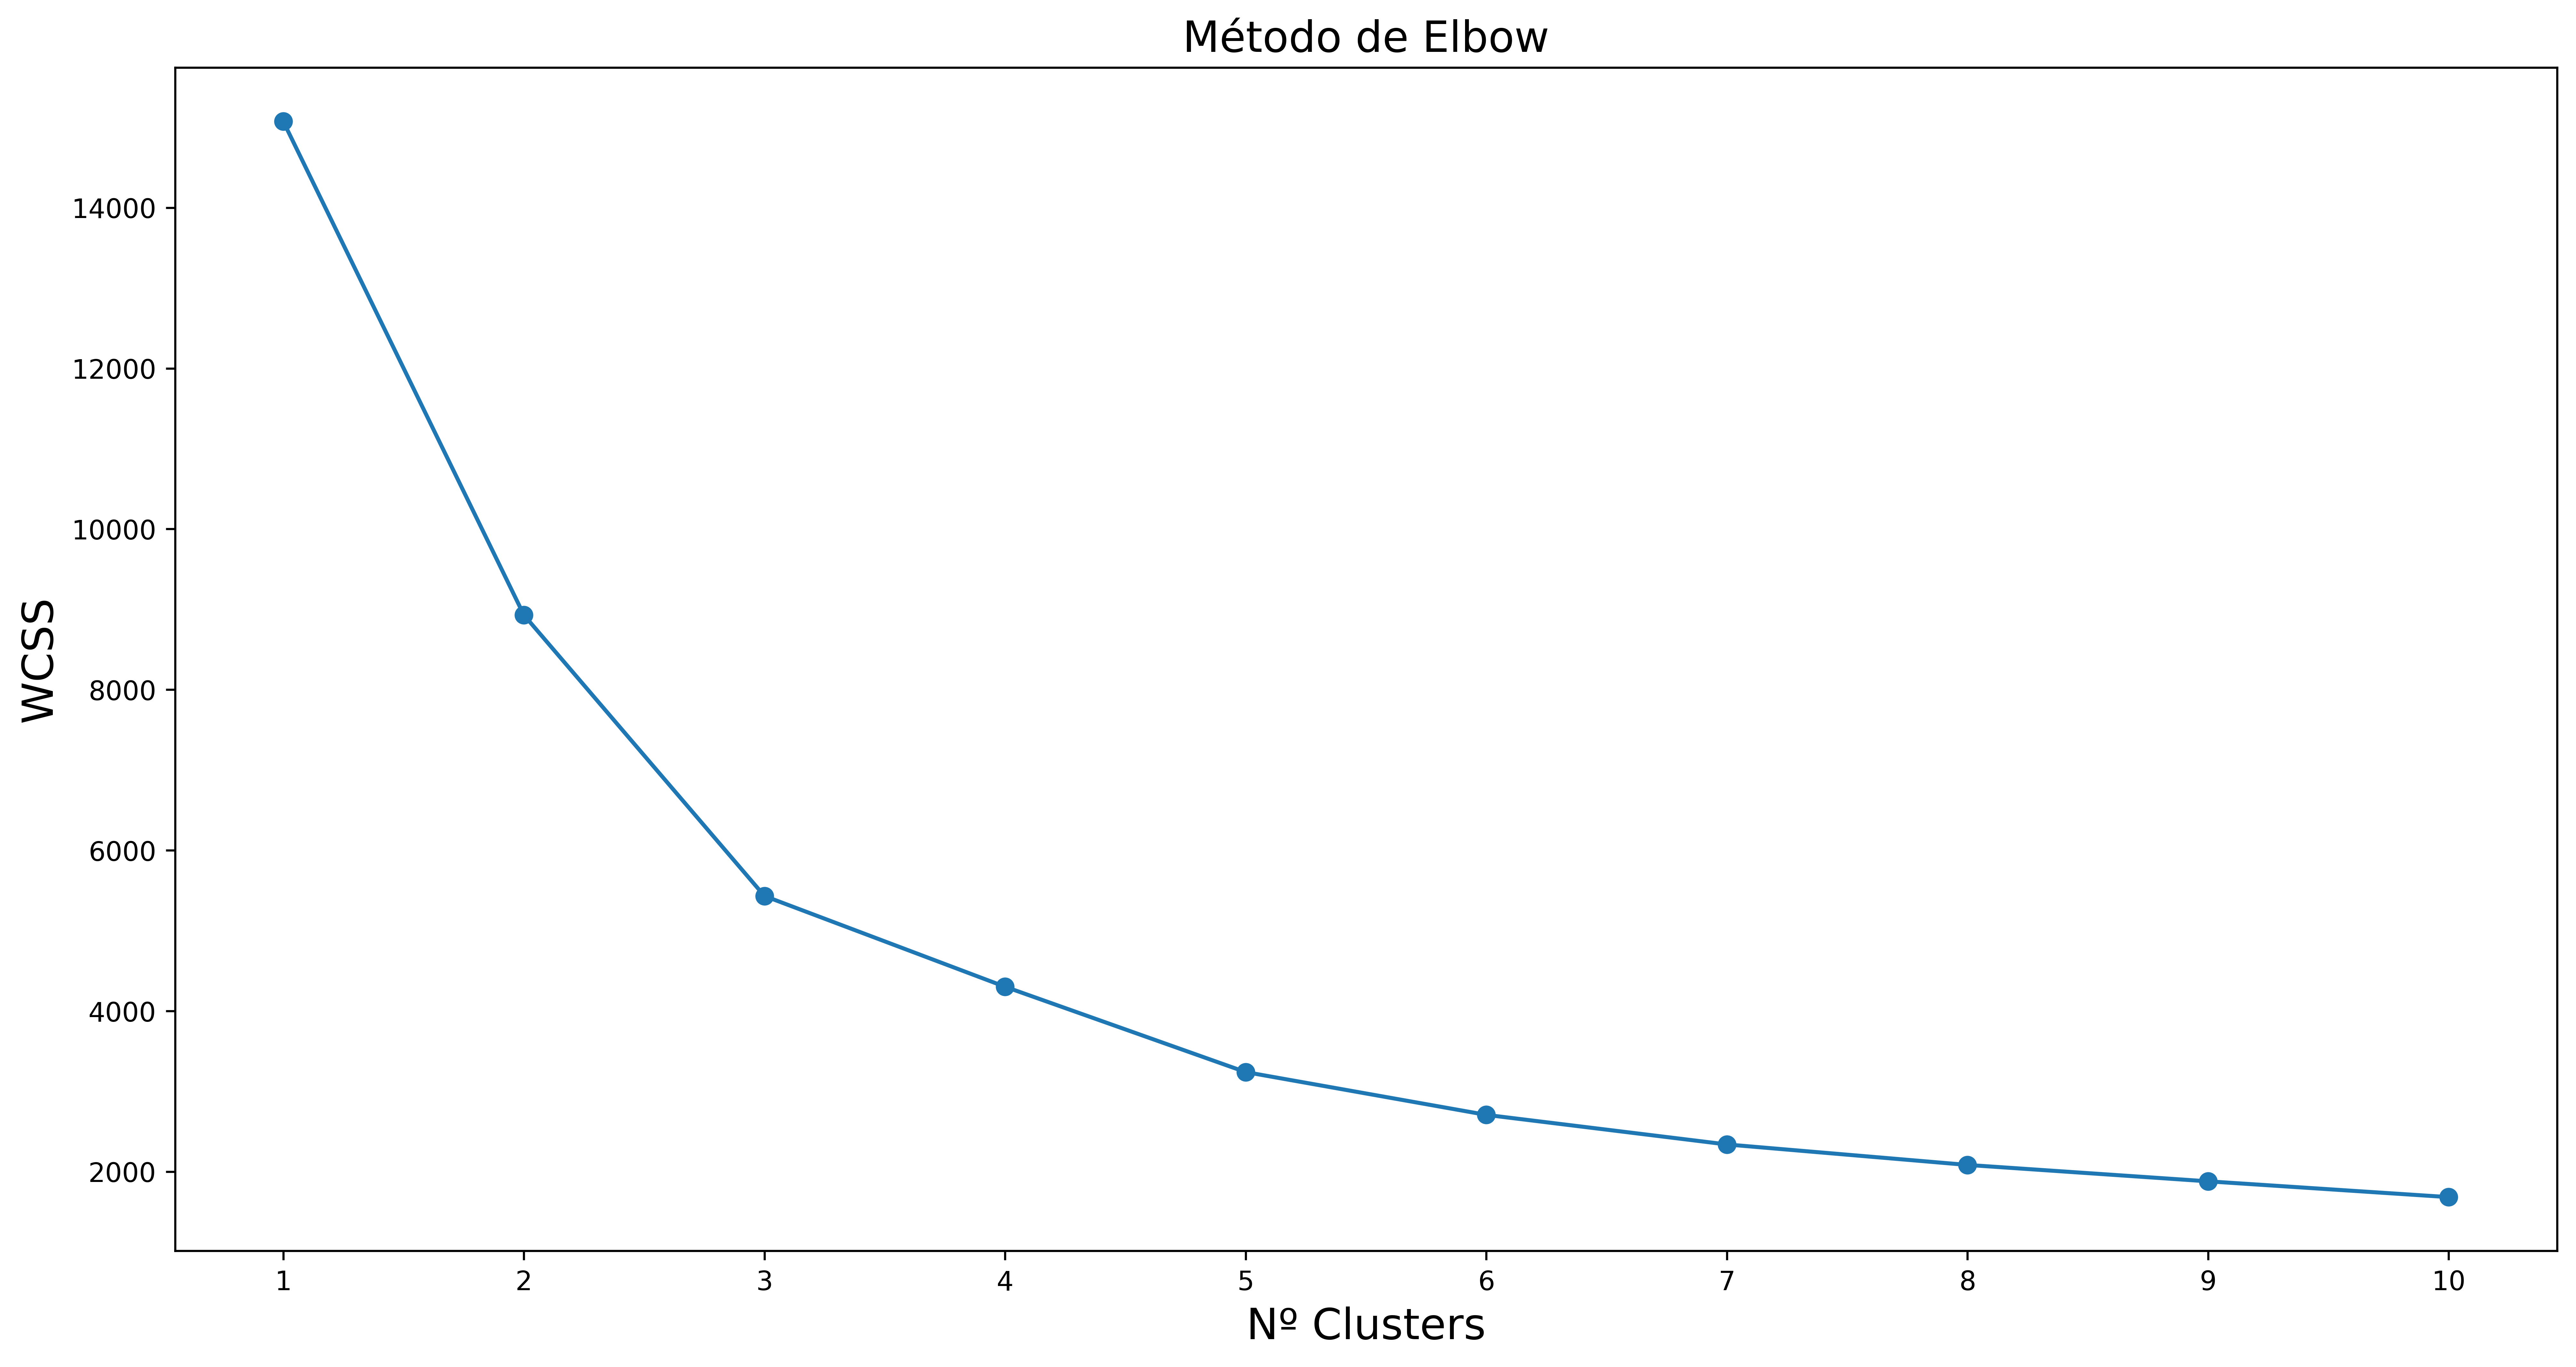

In [27]:
elbow = []
K = range(1, 11)
for k in K:
    kmeanElbow = KMeans(n_clusters=k, init='random', random_state=100).fit(df_quanti_pad)
    elbow.append(kmeanElbow.inertia_)

plt.figure(figsize=(16, 8), dpi=600)
plt.plot(K, elbow, marker='o')
plt.xlabel('Nº Clusters', fontsize=16)
plt.xticks(range(1, 11))
plt.ylabel('WCSS', fontsize=16)
plt.title('Método de Elbow', fontsize=16)
plt.show()

### 💡 Interpretação

> O gráfico mostra a redução do **WCSS** à medida que K aumenta.  
> O ponto onde a curva “dobra” (cotovelo) indica o K ótimo — adicionar mais clusters além desse ponto traz ganho marginal pequeno.  
> Use este resultado em conjunto com o método da Silhueta para uma decisão mais robusta.

## 🔮 Método da Silhueta — Confirmação do Número de Clusters

- Testa K de 2 a 10 e calcula o **coeficiente de silhueta médio** de cada configuração
- O K com **maior coeficiente** indica a melhor separação entre clusters
- A linha pontilhada vermelha marca automaticamente o K ótimo

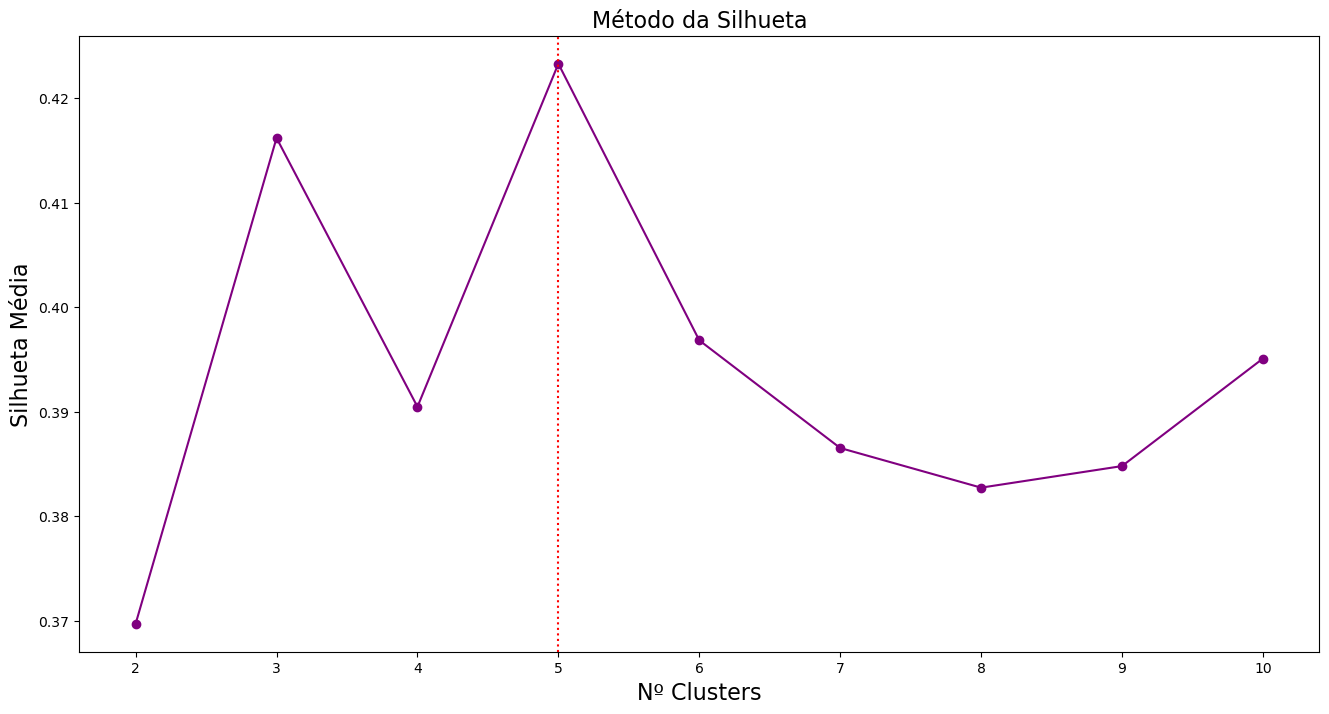

In [28]:
silhueta = []
I = range(2, 11)
for i in I:
    kmeansSil = KMeans(n_clusters=i, init='random', random_state=100).fit(df_quanti_pad)
    silhueta.append(silhouette_score(df_quanti_pad, kmeansSil.labels_))

plt.figure(figsize=(16, 8))
plt.plot(range(2, 11), silhueta, color='purple', marker='o')
plt.xlabel('Nº Clusters', fontsize=16)
plt.ylabel('Silhueta Média', fontsize=16)
plt.title('Método da Silhueta', fontsize=16)
plt.axvline(x=silhueta.index(max(silhueta)) + 2, linestyle='dotted', color='red')
plt.show()

### 💡 Interpretação

> O **coeficiente de silhueta** varia de **−1 a +1**:  
> - Próximo de **+1** → observações bem alocadas no próprio cluster e distantes dos demais  
> - Próximo de **0** → observações na fronteira entre clusters  
> - Próximo de **−1** → observações possivelmente mal alocadas  
> A linha pontilhada vermelha aponta o K com maior silhueta média, confirmando (ou refinando) a escolha do Elbow.

## ⚙️ K-Means Final — Modelo com 5 Clusters

- Com base nas evidências do Elbow e da Silhueta, adotamos **K = 5**
- Os rótulos dos clusters são adicionados tanto ao dataset padronizado quanto ao dataset original

In [29]:
kmeans_final = KMeans(n_clusters=5, init='random', random_state=100).fit(df_quanti_pad)

kmeans_clusters = kmeans_final.labels_
clientes['Cluster'] = kmeans_clusters
df_quanti_pad['Cluster'] = kmeans_clusters

clientes['Cluster'] = clientes['Cluster'].astype('category')
df_quanti_pad['Cluster'] = df_quanti_pad['Cluster'].astype('category')

clientes['Cluster'].value_counts().sort_index()

Cluster
0     782
1    1354
2    2474
3    1603
4    1325
Name: count, dtype: int64

## 🧪 ANOVA — Validação das Variáveis de Clusterização

- Verifica se cada variável quantitativa apresenta **médias significativamente diferentes entre os clusters**
- Critério: **p-valor < 0,05** → a variável é relevante para distinguir os grupos
- Variáveis sem diferença significativa entre clusters poderiam ser removidas da análise

In [30]:
# ANOVA para Age
print('=== ANOVA: Age ===')
print(pg.anova(dv='Age', between='Cluster', data=df_quanti_pad, detailed=True).T)

# ANOVA para FamilySize
print('\n=== ANOVA: FamilySize ===')
print(pg.anova(dv='FamilySize', between='Cluster', data=df_quanti_pad, detailed=True).T)

=== ANOVA: Age ===
                  0            1
Source      Cluster       Within
SS      5741.233311  1795.766689
DF                4         7533
MS      1435.308328     0.238387
F       6020.925602          NaN
p-unc           0.0          NaN
np2         0.76174          NaN

=== ANOVA: FamilySize ===
                  0           1
Source      Cluster      Within
SS       6093.24086  1443.75914
DF                4        7533
MS      1523.310215    0.191658
F       7948.068021         NaN
p-unc           0.0         NaN
np2        0.808444         NaN


### 💡 Interpretação

> **p-valor < 0,05** em ambas as ANOVAs → as médias de `Age` e `FamilySize` são estatisticamente diferentes entre os clusters.  
> Isso confirma que as duas variáveis são **relevantes** para a formação dos grupos e que a segmentação capturou padrões reais nos dados.  
> A estatística **F** alta e o **η²** (eta-quadrado) indicam o tamanho do efeito: quanto da variância da variável é explicada pelo pertencimento ao cluster.

## 📊 Perfil Médio dos Clusters

- Calcula a **média de `Age` e `FamilySize`** por cluster
- Permite nomear e interpretar cada segmento de clientes com base em suas características demográficas

In [31]:
clientes[['Age', 'FamilySize', 'Cluster']].groupby(by=['Cluster']).mean().round(2)

C:\Users\felipe.apolonio_indi\AppData\Local\Temp\ipykernel_55936\237133894.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Age,FamilySize
Cluster,,
0,30.91,5.87
1,70.04,1.79
2,38.56,1.59
3,28.44,3.44
4,51.39,3.76


---
# 🗺️ Parte 2 — Análise de Correspondência Múltipla (ACM)

## 🔀 Preparação das Variáveis Qualitativas

- A ACM opera exclusivamente sobre **variáveis categóricas**
- Incluímos a variável `Cluster` (gerada pelo K-Means) para visualizar no mapa perceptual como os clusters se posicionam em relação ao perfil qualitativo dos clientes

In [32]:
df_quali = clientes[['Gender', 'EverMarried', 'Graduated', 'SpendingScore', 'Cluster']]
df_quali.shape
print(df_quali.head())

   Gender EverMarried Graduated SpendingScore Cluster
0    Male          No        No           Low       3
1  Female         Yes       Yes       Average       3
2  Female         Yes       Yes           Low       1
3    Male         Yes       Yes          High       1
4  Female         Yes       Yes          High       0


## 📊 Tabelas de Frequências

- Distribuição de cada variável qualitativa
- Verifica se alguma categoria possui frequência muito baixa, o que poderia distorcer a ACM

In [33]:
for col in df_quali.columns:
    print(f'\n--- {col} ---')
    print(df_quali[col].value_counts())


--- Gender ---
Gender
Male      4163
Female    3375
Name: count, dtype: int64

--- EverMarried ---
EverMarried
Yes    4466
No     3072
Name: count, dtype: int64

--- Graduated ---
Graduated
Yes    4731
No     2807
Name: count, dtype: int64

--- SpendingScore ---
SpendingScore
Low        4504
Average    1888
High       1146
Name: count, dtype: int64

--- Cluster ---
Cluster
2    2474
3    1603
1    1354
4    1325
0     782
Name: count, dtype: int64


## 🧪 Testes Qui-Quadrado — Associação entre Variáveis

- A ACM exige que haja **associação estatística** entre as variáveis
- Usamos `SpendingScore` como referência e testamos todas as demais
- Critério: **p-valor < 0,05** → associação significativa

In [34]:
variaveis = ['Gender', 'EverMarried', 'Graduated', 'Cluster']

for var in variaveis:
    tabela = pd.crosstab(df_quali['SpendingScore'], df_quali[var])
    _, p, _, _ = chi2_contingency(tabela)
    print(f'SpendingScore vs {var}: p-valor = {round(p, 4)}')

SpendingScore vs Gender: p-valor = 0.0
SpendingScore vs EverMarried: p-valor = 0.0
SpendingScore vs Graduated: p-valor = 0.0
SpendingScore vs Cluster: p-valor = 0.0


### 💡 Interpretação

> **p-valor < 0,05** → rejeita-se H₀ de independência → há associação entre as variáveis.  
> A confirmação de associação para todos os pares justifica o uso da ACM para capturar a estrutura latente do perfil qualitativo dos clientes.  
> Caso alguma variável não apresentasse associação, deveria ser testada com outra referência ou excluída.

## ⚙️ Elaboração da ACM

- Ajustamos a ACM com **3 componentes** para permitir um mapa perceptual tridimensional
- A viabilidade das dimensões será avaliada pelos autovalores em seguida

In [35]:
mca = prince.MCA(n_components=3).fit(df_quali)
print('ACM ajustada com sucesso.')

ACM ajustada com sucesso.


## 📈 Análise dos Autovalores da ACM

- Os **autovalores** medem a inércia (variância) capturada por cada dimensão
- Plotamos apenas dimensões com **inércia parcial superior à inércia média** (critério de seleção)
- `mca.J_` = número total de categorias; `mca.K_` = número de variáveis

In [36]:
# Tabela de autovalores
tabela_autovalores = mca.eigenvalues_summary
print(tabela_autovalores)

# Inércia total
print(f'\nInércia total: {mca.total_inertia_:.4f}')

# Limiar de inércia média (dimensões acima desse valor são representativas)
quant_dim = mca.J_ - mca.K_
limiar = mca.total_inertia_ / quant_dim
print(f'Inércia média por dimensão (limiar): {limiar:.4f}')

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.442        24.55%                     24.55%
1              0.270        15.00%                     39.55%
2              0.238        13.21%                     52.76%

Inércia total: 1.8000
Inércia média por dimensão (limiar): 0.2000


### 💡 Interpretação

> Dimensões com inércia parcial **acima do limiar** são consideradas representativas e devem compor o mapa perceptual.  
> Na ACM, o número de dimensões úteis é tipicamente menor do que o número total de categorias menos o número de variáveis.  
> A inércia total quantifica o quanto de variação existe no conjunto categórico; maior inércia total indica maior diversidade nas associações.

## 📍 Coordenadas-Padrão das Categorias

- As **coordenadas-padrão** posicionam cada categoria das variáveis no espaço dimensional da ACM
- Categorias próximas no mapa perceptual tendem a ocorrer juntas nas mesmas observações

In [37]:
coord_padrao = mca.column_coordinates(df_quali) / np.sqrt(mca.eigenvalues_)
print(coord_padrao.round(4))

                             0       1       2
Gender__Female         -0.2365 -0.6539 -0.7379
Gender__Male            0.1918  0.5301  0.5982
EverMarried__No        -1.6013 -0.1627 -0.0411
EverMarried__Yes        1.1015  0.1119  0.0283
Graduated__No          -0.7634  1.3811  0.8613
Graduated__Yes          0.4529 -0.8194 -0.5110
SpendingScore__Average  1.4245 -1.1214  1.8358
SpendingScore__High     1.6107  2.4338 -1.7079
SpendingScore__Low     -1.0070 -0.1492 -0.3350
Cluster__0             -1.2249  1.3110  1.1231
Cluster__1              1.1639  1.9137 -2.5084
Cluster__2             -0.2593 -1.9367 -0.9505
Cluster__3             -1.3878  0.9567  1.1354
Cluster__4              1.6966 -0.2705  2.3015


## 🗺️ Mapa Perceptual 3D — ACM (Coordenadas-Padrão)

- Gera um scatter 3D interativo com `plotly`, onde cada ponto representa uma categoria
- Cores distintas identificam cada variável
- O arquivo `segmenta.html` é salvo para visualização e compartilhamento

In [38]:
chart = coord_padrao.reset_index()
var_chart = pd.Series(chart['index'].str.split('_', expand=True).iloc[:, 0])

nome_categ = []
for col in df_quali:
    nome_categ.append(df_quali[col].sort_values(ascending=True).unique())
    categorias = pd.DataFrame(nome_categ).stack().reset_index()

chart_df_mca = pd.DataFrame({
    'categoria': chart['index'],
    'obs_x': chart[0],
    'obs_y': chart[1],
    'obs_z': chart[2],
    'variavel': var_chart,
    'categoria_id': categorias[0]
})

fig = px.scatter_3d(
    chart_df_mca,
    x='obs_x',
    y='obs_y',
    z='obs_z',
    color='variavel',
    text=chart_df_mca.categoria_id
)

fig.write_html('segmenta.html')
fig.show()

### 💡 Interpretação

> O mapa perceptual 3D posiciona as **categorias das variáveis qualitativas** no espaço da ACM.  
> **Categorias próximas** entre si tendem a coocorrer nos mesmos clientes — formando **perfis latentes**.  
> A presença dos **clusters** (gerados pelo K-Means) no mapa permite verificar visualmente a relação entre o segmento demográfico e o perfil qualitativo.  
> Clusters posicionados próximos de categorias específicas (ex.: `SpendingScore: High`, `Graduated: Yes`) revelam características comportamentais predominantes naquele segmento.

---
# ✅ Conclusão

Esta análise de segmentação combinou duas técnicas complementares para capturar a estrutura completa do dataset:

| Etapa | Técnica | Objetivo |
|-------|---------|----------|
| 1 | **K-Means** | Segmentar clientes com base em variáveis quantitativas (`Age`, `FamilySize`) |
| 2 | **ANOVA** | Validar que as variáveis discriminam significativamente os clusters |
| 3 | **ACM** | Mapear associações entre variáveis qualitativas + clusters no espaço perceptual 3D |

O resultado é uma visão integrada dos segmentos de clientes: **quem são demograficamente** (K-Means) e **como se comportam qualitativamente** (ACM).